In [1]:
using CSV, DataFrames             # Pour charger et organiser les données
using Gadfly                      # Pour générer des graphiques
using Distributions               # Pour utiliser les distributions statistiques
using GLM                         # Librairie pour la régression et les modèles linéaires généralisés
using LinearAlgebra               # Pour utiliser les fonctions d'algèbre linéaire
using MLBase 

In [2]:
# Chargement de l'ensemble d'entraînement
data = CSV.read("Train.csv", DataFrame)

# Calcul de la proportion empirique de survivants
θ̂ = sum(data.Survived)/nrow(data)

0.38646788990825687

In [3]:
# Chargement des solutions
solutions = CSV.read("/Users/jalbert/Library/CloudStorage/Dropbox/Files/Teaching/MTH3302/Data/Titanic/Solution.csv",
    DataFrame)

# Définition du ground truth
y = solutions.Survived ;

# Règle 1

In [4]:
ŷ = fill(0, length(y)) ;

## Calcul du pourcentage de bonne classification

In [5]:
p̂ = correctrate(y, ŷ)

0.6270022883295194

# Règle 2

In [6]:
n = length(ŷ)

p = Float64[]
pd = Binomial(1,θ̂)

for i in 1:1000
    ŷ = rand(pd, n)
    push!(p, correctrate(y, ŷ))
end

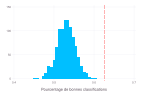

In [7]:
plot(x=p, Geom.histogram(bincount=30),
    xintercept = [p̂], Geom.vline(color="red", style=:dash),
    Guide.xlabel("Pourcentage de bonnes classifications"))

In [8]:
# proportion empiriques de bonnes classifications
mean(p)

0.5291670480549199

In [9]:
# probabilité de bonnes classifications
1-2*θ̂*(1-θ̂)

0.5257790800437674

# Pourcentage de bonne classification en fonction des règles de décision

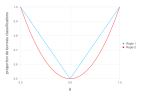

In [10]:
l1 = layer(x -> (x < 1/2) ? (1-x) : x , 0, 1)
l2 = layer(x -> x^2 + (1-x)^2, 0, 1, Theme(default_color=colorant"red"))

plot(l1, l2, 
    Guide.xlabel("θ"), Guide.ylabel("proportion de bonnes classifications"),
    Guide.manual_color_key("",["Règle 1","Règle 2"],
                            [Gadfly.current_theme().default_color,"red"]))

In [14]:
length(y) - sum(y)

274

In [13]:
length(y)

437

In [15]:
solutions

Row,PassengerId,Survived
,Int64,Int64
1,1,1
2,3,0
3,4,0
4,5,0
5,8,0
6,9,1
7,10,1
8,11,1
9,13,0


In [16]:
test

LoadError: UndefVarError: `test` not defined

In [22]:
test = CSV.read("Test.csv", DataFrame)
test.Survived = y
test.Pclass = string.(test.Pclass)
first(test, 5)

Row,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
,Int64,String,String,String7,Float64?,Int64,Int64,String31,Float64?,String15?,String1?,Int64
1,1,1,"Kenyon, Mrs. Frederick R (Marion)",female,missing,1,0,17464,51.8625,D21,S,1
2,3,3,"Lockyer, Mr. Edward",male,missing,0,0,1222,7.8792,missing,S,0
3,4,3,"Saad, Mr. Amin",male,missing,0,0,2671,7.2292,missing,C,0
4,5,3,"Johansson, Mr. Nils",male,29.0,0,0,347467,7.8542,missing,S,0
5,8,1,"Rowe, Mr. Alfred G",male,33.0,0,0,113790,26.55,missing,S,0


In [23]:
df = combine(groupby(test, :Pclass),:Survived => length =>:Nombre,  :Survived => sum =>:Survivants)

Row,Pclass,Nombre,Survivants
,String,Int64,Int64
1,1,115,65
2,3,232,56
3,2,90,42


In [24]:
df.Morts = df.Nombre - df.Survivants
df = df[[1,3,2],:]

Row,Pclass,Nombre,Survivants,Morts
,String,Int64,Int64,Int64
1,1,115,65,50
2,2,90,42,48
3,3,232,56,176


In [25]:
48+176

224

In [26]:
5/(5+9)

0.35714285714285715

In [27]:
224/(224+50)

0.8175182481751825